# Analyse d'un portefeuille bancaire avec Python & SQL
## Présentation du projet
Ce projet a pour objectif d'analyser un portefeuille de clients bancaires à l'aide de **Python, SQL et Matplotlib**.
L'analyse porte notamment sur la segmentation de la clientèle, les produits bancaires détenus, les volumes de transactions et les montants associés. L'objectif est d'plorer les données, d'identifier les principales tendance du portefeuille et de produire des indicateurs utiles à l'analyse de l'activité bancaire.
### Objectifs
- Préparer et contrôler la qualité des données clients
- Explorer le portefeuille bancaire avec Python et Pandas
- Interroger les données à l'aide de SQL
- Comparer les différents segments de clientèle
- Analyser les produits bancaires
- Identifier les clients présentant les montants les plus importants
- visualiser les principaux indicateurs
- Dégager des enseignements utiles à la prise de décision
### Technologies utilisées
- Python
- Pandas
- SQL
- SQLite
- Manpltlib
- Google Colab



## 1. Présentation et préparation des données
Le jeu de données utilisé dans ce projet contient des informations relatives à un portefeuille de clients bancaires.
Les principales variables étudiées sont:
- ** Client_ID** : identifiant unique du client
- **Age** : age du client
- **Segment** : catégorie de clientèle (Standard, Premium ou professionnel)
- **Région** : région du client
- **Produit** : produit bancaire détenu
- **Date** : date associée à l'observation
- **NB_Transactions** : nombre de transaction
- **Montant_Total_EUR** : montant total associé au client en euros
- **Satisfaction** : indicateur de satisfaction client
### Contrôle de la qualité des données
Avant l'analyse, plusieurs vérifications on été effectuées afin de garantir la qualité du jeu de données:
- Recherche des valeurs manquantes;
- Vérification des doublons;
- Contrôle de l'unicité des identifiants clients;
- Vérification des types de données.
Les contrôles n'ont révélé aucune valeur manquante ni aucun doublon.

## 2. Analyse SQL du portefeuille bancaire
Objectif : exploiter SQL afin d'analyser le portefeuille clients, identifier les segments et produits les plus importants et faire ressortir des informations utiles à la prise de décision.

### 2.1 Présentation des données
Le jeu de données contient 120 clients bancaires et 11 variables.
- Le segment client;
- La région;
- Le produit bancaire;
- Le nombre de transaction;
- Le montant total en euros;
- Le niveau de satisfaction.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/banque.csv")

In [3]:
df .head()

,Client_ID,Age,Segment,Region,Produit,Date,Nb_Transactions,Montant_Total_EUR,Satisfaction,Montant_total_EUR_corrigé,Colonne 1
0,C001,62,Standard,Normandie,Épargne,2025-08-05,19,6600.04,5,"6600,04",TRUE
1,C002,24,Standard,Hauts-de-France,Épargne,2025-04-23,37,28977.76,4,"28977,76","1621164,27"
2,C003,50,Premium,Île-de-France,Épargne,2025-07-14,32,12726.58,1,"12726,58","74943,27"
3,C004,28,Standard,Normandie,Crédit,2025-05-31,7,12317.72,5,"12317,72","12726,58"
4,C005,62,Premium,Normandie,Épargne,2025-02-21,9,4198.53,2,"4198,53","40461,6"


In [4]:
df .shape

(120, 11)

In [5]:
df .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Client_ID                  120 non-null    object 
 1   Age                        120 non-null    int64  
 2   Segment                    120 non-null    object 
 3   Region                     120 non-null    object 
 4   Produit                    120 non-null    object 
 5   Date                       120 non-null    object 
 6   Nb_Transactions            120 non-null    int64  
 7   Montant_Total_EUR          120 non-null    float64
 8   Satisfaction               120 non-null    int64  
 9   Montant_total_EUR_corrigé  120 non-null    object 
 10  Colonne 1                  8 non-null      object 
dtypes: float64(1), int64(3), object(7)
memory usage: 10.4+ KB


In [7]:
import sqlite3

In [8]:
conn = sqlite3.connect("banque.db")

In [9]:
df .to_sql("clients", conn, if_exists="replace", index=False)

120

### 2.2 Requêtes SQL
#### 2.2.1 Apercu de la table client
Cette première requête permet d'afficher un échantillon de la table 'clients' afin de vérifier sa structure et les principales variables disponibles avant de poursuivre l'analyse.

In [10]:
query = """
SELECT *
FROM clients
LIMIT 5;
"""
pd.read_sql(query, conn)


,Client_ID,Age,Segment,Region,Produit,Date,Nb_Transactions,Montant_Total_EUR,Satisfaction,Montant_total_EUR_corrigé,Colonne 1
0,C001,62,Standard,Normandie,Épargne,2025-08-05,19,6600.04,5,"6600,04",TRUE
1,C002,24,Standard,Hauts-de-France,Épargne,2025-04-23,37,28977.76,4,"28977,76","1621164,27"
2,C003,50,Premium,Île-de-France,Épargne,2025-07-14,32,12726.58,1,"12726,58","74943,27"
3,C004,28,Standard,Normandie,Crédit,2025-05-31,7,12317.72,5,"12317,72","12726,58"
4,C005,62,Premium,Normandie,Épargne,2025-02-21,9,4198.53,2,"4198,53","40461,6"


#### 2.2.2 Montant total par segment de clientèle
Cette requê agrège les montants du portefeuille par segment de clientèle afin d'identifier les segment représentant les volumes financiers les plus importants.

In [11]:
query = """
SELECT
  Segment,
  Sum(Montant_Total_EUR) AS Montant_total
FROM clients
GROUP BY Segment
ORDER BY Montant_Total DESC;
"""
pd .read_sql(query, conn)

,Segment,Montant_total
0,Standard,935824.71
1,Premium,426173.72
2,Professionnel,259165.84


**Interprétation :**
Le segment Standard représente le montant total le plus élevé du portefeuille avec environ 935 825 € devant le segment Premium avec environ 426 174 € et le segment professionnel avec environ 259 166 €. Le segment Standard constitue la principale contribution au volume financier du portefeuille.

#### 2.2.3 Répartition des clients par segemnet
Cette requête permet de déterminer le nombre de clients appartenant à chaque segment afin d'analyser la composition du portefeuille bancaire.

In [14]:
query = """
SELECT Segment, COUNT(*) AS Nomber_clients
FROM clients
GROUP BY Segment;
"""
pd.read_sql(query, conn)

,Segment,Nomber_clients
0,Premium,37
1,Professionnel,20
2,Standard,63


**Interprétation :**
Le segment Standard est majoritaire avec 63 clients sur 120? soit 52,5 % du portefeuille. Le segment Premium compte 37 client (30,8 %) et le segment Professionnel 20 clients (16,7 %). La clientèle du portefeuille est donc principalement constituée de clients Standard.

#### 2.2.4 Montant total par produit bancaire
Cette requête permet de calculer le montant total associé à chaque produit bancaire afin d'identifier les produits représentant les volumes financiers les plus importants du portefeuille.

In [18]:
query = """
SELECT produit,
 SUM(Montant_total_EUR_corrigé) AS Montant_total
FROM clients
GROUP BY produit;
"""
pd.read_sql(query, conn)

,Produit,Montant_total
0,Carte bancaire,119571.0
1,Compte courant,156177.0
2,Crédit,788370.0
3,Épargne,556987.0


**Interprétation :**
Le Crédit représente le volume financier le plus important du portefeuille avec environ 788 370 €, suivi de l'Epargne avec environ 556 987 €. Le Compte courant et la Carte bancaire présentent des montants plus faibles, respectivement d'environ 156 177 € et 119 571 €. Les produits Crédit et Epargne concentrent ainsi l'essentiel des montants du portefeuille.

In [24]:
query = """
SELECT Produit,
  SUM(Montant_Total_EUR) AS Montant_total
FROM clients
GROUP BY Produit
ORDER BY Montant_total DESC;
"""

pd.read_sql(query, conn)


,Produit,Montant_total
0,Crédit,788386.32
1,Épargne,557000.86
2,Compte courant,156190.78
3,Carte bancaire,119586.31


In [38]:
query = """
SELECT
SUM(Montant_Total_EUR) AS Montant_Standard_Île_de_France
FROM clients
WHERE Segment = 'Standard'
AND Region = 'Île-de-France';
"""
pd.read_sql(query, conn)

,Montant_Standard_Île_de_France
0,129249.47


**Interprétation :**
Le segment Standard en Île-de-France représente un montant total d'environ 129 249 €. Cette analyse croisée entre le segment de clientèle et la région permet de d'identifier la contribution financière d'une catégorie de clients sur une zone géographique précise.

In [39]:
query = """
SELECT
Segment,
AVG(Montant_total_EUR) AS Montant_moyen
FROM clients
GROUP by Segment;
"""
pd.read_sql(query,conn)

,Segment,Montant_moyen
0,Premium,11518.208649
1,Professionnel,12958.292000
2,Standard,14854.360476


**Interprétation :**
Le segment Standard présente le montant moyen le plus élevé, avec environ 14 854 € par client, devant le segment Professionnel avec environ 12 958 € et le segment Premium avec environ 11 518 €. Ce résultat montre que le segment générant le montant total le plus important n'est pas nécessairement celui présentant le montant moyen individuel le plus élevé.

In [40]:
query = """
SELECT
Client_ID,
Region,
Produit,
Montant_Total_EUR
FROM clients
ORDER BY Montant_Total_EUR DESC
LIMIT 5;
"""
pd.read_sql(query, conn)


,Client_ID,Region,Produit,Montant_Total_EUR
0,C075,Grand Est,Crédit,74943.27
1,C109,Bretagne,Crédit,61127.92
2,C088,Île-de-France,Crédit,53744.97
3,C111,Bretagne,Crédit,50647.90
4,C033,Île-de-France,Crédit,49239.69


**Interprétation :**
L'analyse des cinq requêtes clients présentant les montants les plus élevés montre que le client C075 arrive en tête avec 74 943,27 €, suivi du client C109 avec 61 127,92 €. Les cinq clients du classement détiennent tous un produit crédit, ce qui met en évidence le poids important de ce produit parmis les montants les plus élevés du portefeuille.

##Création de la base de données SQLite
Les données préparées avec Pandas sont itégrées dans une base SQLite afin de permettre leur interrogation à l,aide de requêtes SQL.

In [12]:
import sqlite3
conn = sqlite3.connect("/content/drive/MyDrive/Projet_Portefeuille_Bancaire/banque.db")
print("connexion à la base réussie")


connexion à la base réussie


In [16]:
df.to_sql("clients", conn, if_exists="replace", index=False)
print("Table clients créée avec succès")

Table clients créée avec succès


In [18]:
query = """
SELECT COUNT (*) AS Nombre_clients
FROM clients;
"""
pd.read_sql(query, conn)

,Nombre_clients
0,120


In [19]:
query = """
SELECT Segment,
COUNT(*) AS Nombre_clients
FROM clients
GROUP BY Segment
ORDER BY Nombre_clients DESC;
"""
pd.read_sql(query, conn)

,Segment,Nombre_clients
0,Standard,63
1,Premium,37
2,Professionnel,20


**Interprétation :**
Le portefeuille est majoritairement composé des clients du segment Standard, avec 63 clients sur 120. Le segment Premium compte 37 clients, tandis que le segment Professionnel représente 20 clients. Cette répartion montre que la clientèle Standard constitut la part la plus importante du portefeuille.

In [28]:
query = """
SELECT Client_ID,
Segment,
Region,
Produit,
Montant_Total_EUR
FROM clients
ORDER BY Montant_Total_EUR DESC
LIMIT 10;
"""
top10 = pd.read_sql(query, conn)
top10

,Client_ID,Segment,Region,Produit,Montant_Total_EUR
0,C075,Premium,Grand Est,Crédit,74943.27
1,C109,Standard,Bretagne,Crédit,61127.92
2,C088,Premium,Île-de-France,Crédit,53744.97
3,C111,Standard,Bretagne,Crédit,50647.90
4,C033,Premium,Île-de-France,Crédit,49239.69
5,C028,Standard,Grand Est,Crédit,48110.09
6,C093,Standard,Normandie,Crédit,44336.42
7,C042,Standard,Grand Est,Épargne,40926.51
8,C007,Standard,Hauts-de-France,Épargne,40461.60
9,C013,Standard,Île-de-France,Crédit,38739.19


##Top 10 des clients par montant total
Cette analyse permet d'identifier les clients générant les montants financiers les plus élevé du portefeuille. Le client C075 arrive en tête avec un montant total de 74 943,27. L'identification de ces clients à forte valeur peut notamment aider à orienter les actions de fidélisation et de suivi commercial.

In [33]:
query = """
SELECT Produit,
COUNT(*) AS Nombre_clients,
ROUND (AVG(Montant_Total_EUR), 2) AS Montant_moyen
FROM clients
GROUP BY Produit
ORDER BY Montant_moyen DESC;
"""
analyse_produits = pd.read_sql(query, conn)
analyse_produits

,Produit,Nombre_clients,Montant_moyen
0,Crédit,30,26279.54
1,Épargne,31,17967.77
2,Compte courant,27,5784.84
3,Carte bancaire,32,3737.07


## Analyse des produits bancaires
La carte bancaire est le produit le plus répendu avec 32 clients, suivie de l'épargne avec 31 clients. Toutefois, le crédit présente le montant moyen le plus élevé, avec 26 279,54 €, devant l'épargne avec 17 967,77 €. Ces résultats montrent que le produit le plus fréquemment détenu n'est pas nécessairement celui qui génère les montants financiers moyens les plus importants.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
chemin = "/content/drive/MyDrive/Projet_Portefeuille_Bancaire/banque.csv"
df = pd.read_csv(chemin)

In [12]:
import matplotlib.pyplot as plt

In [10]:
# Vérifier les valeurs manquantes
df.isnull().sum()


,0
Client_ID,0
Age,0
Segment,0
Region,0
Produit,0
Date,0
Nb_Transactions,0
Montant_Total_EUR,0
Satisfaction,0
Montant_total_EUR_corrigé,0


In [12]:
df.isnull().sum()

,0
Client_ID,0
Age,0
Segment,0
Region,0
Produit,0
Date,0
Nb_Transactions,0
Montant_Total_EUR,0
Satisfaction,0
Montant_total_EUR_corrigé,0


In [15]:
df.dtypes

,0
Client_ID,object
Age,int64
Segment,object
Region,object
Produit,object
Date,object
Nb_Transactions,int64
Montant_Total_EUR,float64
Satisfaction,int64
Montant_total_EUR_corrigé,object


In [11]:
df = df.drop(columns=["Colonne 1"])

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["Client_ID"].duplicated().sum()

np.int64(0)

## Nettoyage et contrôle de la qualité des données
La vérification de la qualité des données montre qu'aucune valeur manquante n'est présente dans le jeu de données. aucun doublon n'a également été détecté, aussi bien au niveau des ligne que des identifiants clients (Client_ID). Les types de données ont été contrôlés afin de garantir leur cohérence avec les analyses réalisées. ces vérifications permettent de confirmer que les données utilisées son suffisamment propres, cohérentes et structurées pour poursuivre l'analyse du portefeuille bancaire.

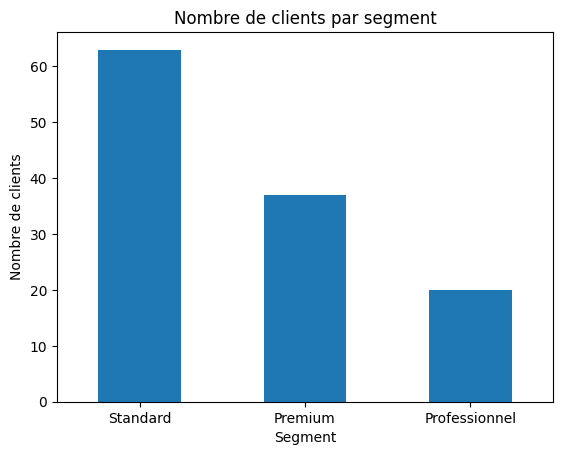

In [18]:
clients_segment = df["Segment"].value_counts()
clients_segment.plot(kind="bar")
plt.title("Nombre de clients par segment")
plt.xlabel("Segment")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.show()

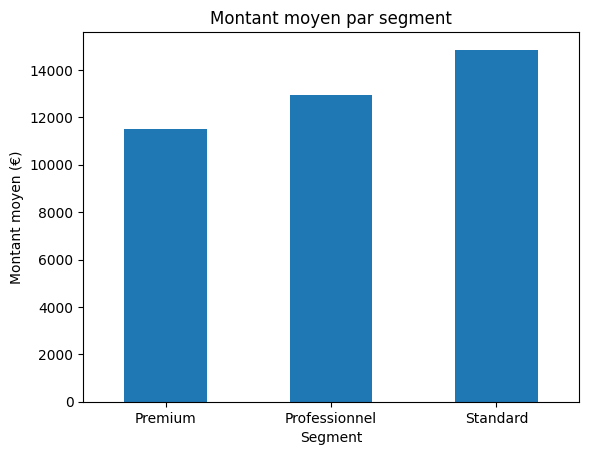

In [16]:
montant_segment = df.groupby("Segment")["Montant_Total_EUR"].mean()
montant_segment.plot(kind="bar")
plt.title("Montant moyen par segment")
plt.xlabel("Segment")
plt.ylabel("Montant moyen (€)")
plt.xticks(rotation=0)
plt.show()

## Analyse du montant moyen par segment
Le segment Standard présente le montant moyen le plus élevé, suivi du segment Professionnel, puis du segment Premium.
Cette analyse montre que le nombre de clients d'un segment n'est pas le seul élément à prendre en compte : la valeur financière moyenne des clients permet également d'identifier les segments les plus importants pour la banque.

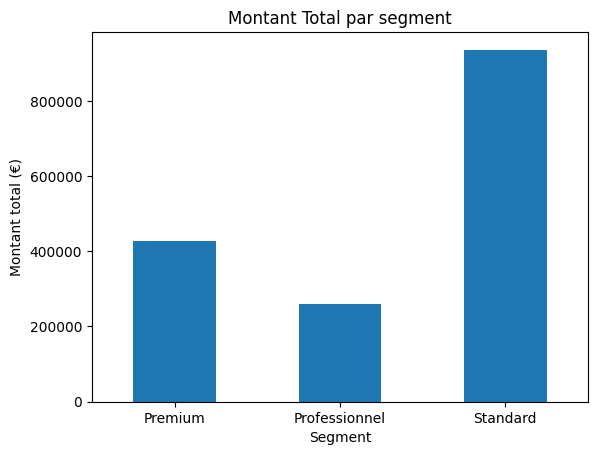

In [6]:
montant_segment = df.groupby("Segment")["Montant_Total_EUR"].sum()
montant_segment.plot(kind="bar")
plt.title("Montant Total par segment")
plt.xlabel("Segment")
plt.ylabel("Montant total (€)")
plt.xticks(rotation=0)
plt.show()


## Analyse du montant total par segment
Le segment Standard génère le montant total le plus élevé, avec environ 935 825 €, suivi du segment Premium avec environ 426 174 €. Le segment professionnel représente environ 259 166 €.

In [43]:
print(df.columns.tolist())

['Client_ID', 'Age', 'Segment', 'Region', 'Produit', 'Date', 'Nb_Transactions', 'Montant_Total_EUR', 'Satisfaction', 'Montant_total_EUR_corrigé', 'Colonne 1']


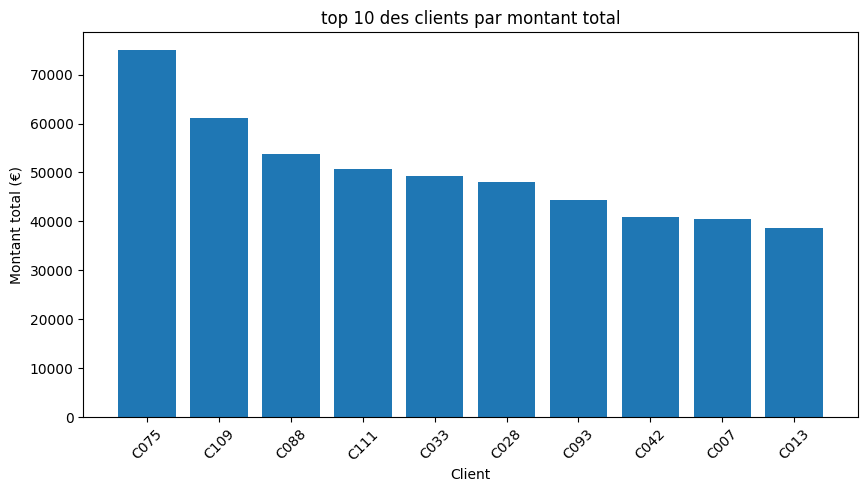

In [9]:
top10 = df.nlargest(10, "Montant_Total_EUR")
plt.figure(figsize=(10,5))
plt.bar(
    top10["Client_ID"],
    top10["Montant_Total_EUR"])
plt.title("top 10 des clients par montant total")
plt.xlabel("Client")
plt.ylabel("Montant total (€)")
plt.xticks(rotation=45)
plt.show()


## Analyse des principaux clients
Le classement des dix clients présentant les montants totaux les plus élevés met en évidence une concentration particulière sur certains clients. Le client C075 se distingue avec le montant le plus important, suivi du client C109. Les autres clients du classement présentent des montants relativement plus proches.
Cette analyse permet d'identifier les clients à forte valeur financière et peut aider la banque à orienter ses actions de fidélisation et de suivi commercial.

# Conclusion de l'analyse
L'analyse des données clients a permis de mettre en évidence plusieurs tendances importantes. Le segment Standard est le plus réprésenté avec 63 clients et génère également le montant total le plus élevé, avec 935824,71 £, devant les segments Premium et Professionnel.

L'analuse du montant moyen montre également des différences entre les segments, permettant de compléter l'étude de leur contribution financière au portefeuille bancaire.


Enfin, l'analyse des clients présentant les montants totaux les plus importants met notamment en évidence C075, C109 et C088. Le client C075 se distingue particulièrement avec le montant total le plus élevé du portefeuille.

Ce projet m'a permis de mettre en pratique la préparation et l'analyse de données avec Python et Pandas, l'inerrogation des données avec SQL, ainsi que la visialisation et l'interprétation des résutats afin d'identifier des informations utiles sur un portefeuille bancaire.